<a href="https://colab.research.google.com/github/erickaylas-zen/FGD_2026/blob/main/FGD_C28R_1A_S6_Grupo3_PMDCheckpoint.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div align="center">

<br>**TECSUP**<br>
**Programa de Formación Regular**<br>
**Departamento de Tecnología Digital**<br>
 **Big Data y Ciencia de Datos**<br><br>
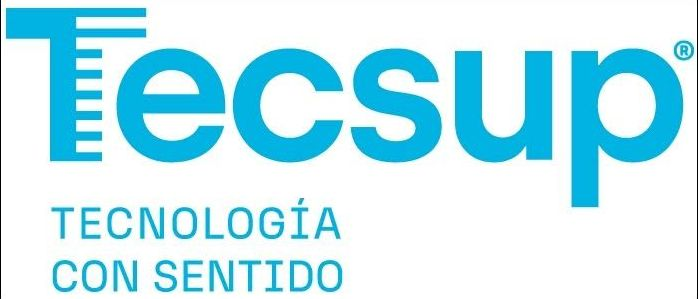 <br><br>**Fundamentos de Gestión de Datos**<br>
<br>
<div align="left">
<div style="font-family: 'Calibri', 'Segoe UI', sans-serif; font-size: 18.5px; color: #FFFFFF; font-weight: bold; line-height: 1.8;">

  <div style="display: flex;">
    <div style="width: 120px; flex-shrink: 0;"><strong>Actividad: Proyecto Integrador de Datos</strong></div>
  </div>
<div align="left" style="display: inline-block; text-align: left;">
    <strong>Nombres: Portocarrero Cossío, José Ramiro</strong><br>
    &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;<strong>Aylas Zenteno, Erick Paul</strong><br>
    &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;<strong>Guzmán Yamunaqué, Sylvia Jannet</strong><br>
    &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;<strong>Ramirez Sanchez, Carlos Lois</strong>
</div>
  <div style="display: flex;">
    <div style="width: 120px; flex-shrink: 0;"><strong>Sección: C28R-1A</strong></div>
  </div>
 <div style="display: flex;">
    <div style="width: 120px; flex-shrink: 0;"><strong>Docente: Pilar Rocío Sayán Mejía</strong></div>
  </div>

</div>
<div align="center"><br><br>
<strong>Lima – Perú</strong><br>
<strong>2026</strong>




DEFINICIÓN DEL PROBLEMA


1. **Contexto del Negocio:** RetailMax es una cadena de tiendas de consumo diario que comercializa productos de alta rotación, artículos de limpieza, alimentos envasados y productos de cuidado personal. La empresa registra información de clientes, productos, sucursales y ventas provenientes de distintos puntos de venta con el objetivo de comprender mejor su desempeño comercial y apoyar la toma de decisiones.
2. **Necesidad del Negocio:**
La gerencia comercial requiere información confiable para identificar los productos y zonas con mejor desempeño, así como estimar el monto de ventas esperado a partir del historial de compras. Para lograrlo, es necesario analizar y validar la calidad de los datos disponibles.
3. **Objetivo analítico del proyecto:** Transformar la información operativa de RetailMax en una fuente confiable para el análisis, permitiendo identificar los productos y zonas con mayor movimiento comercial y estimar el monto de ventas a partir del comportamiento de compra registrado.

EXTRACCION DE LA DATA

In [ ]:
import requests
import sqlite3
import pandas as pd

# 1. Definición de rutas y descarga del archivo .db
BASE_URL = "https://raw.githubusercontent.com/Rociosayan/PMD1_Fundamentos_Gestion_Datos/main"
CASO = "01_retailmax_ventas"
DB_NAME = "retailmax_ventas.db"

url = f"{BASE_URL}/casos/{CASO}/{DB_NAME}"
respuesta = requests.get(url)
respuesta.raise_for_status()

with open(DB_NAME, "wb") as archivo:
    archivo.write(respuesta.content)

# 2. Conectar a la base de datos SQLite
conn = sqlite3.connect(DB_NAME)

# [Opcional] Verificar las tablas existentes (tu código original)
tablas = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conn)
print("Tablas encontradas en la base de datos:")
print(tablas)
print("-" * 50)

# 3. Cargar la tabla de ventas original en el DataFrame solicitado
# Usamos 'ventas' porque es el nombre de la tabla dentro del archivo SQLite
ventas_original = pd.read_sql_query("SELECT * FROM ventas_original;", conn)

# 4. Cerrar la conexión por buena práctica
# conn.close() todavía porque seguiremos usando la data y usando código

# 5. Visualizar las primeras 10 filas
ventas_original.head(20)

Tablas encontradas en la base de datos:
              name
0  ventas_original
--------------------------------------------------


,id_venta,fecha_operacion,cantidad,cantidad_productos,precio_unitario,descuento_pct,canal,metodo_pago,calificacion,monto_total,...,sucursales_nombre,sucursales_distrito,sucursales_zona,productos_nombre,productos_categoria,productos_precio_unitario,clientes_nombre,clientes_distrito,clientes_segmento,clientes_fecha_registro
0,1,2026-06-13,1,5,13.2,0,App,Plin,4,66.00,...,Sucursal 2,VENTANILLA,Oeste,Aceite vegetal,Abarrotes,13.20,Luis Soto,Comas,Nuevo,2025-02-13
1,2,2026-02-14,2,2,10.15,0,Presencial,Plin,1,20.30,...,Sucursal 6,Ate,Sur,Papel higienico,Limpieza,10.15,Carlos Huaman,callao,Frecuente,2025-03-25
2,3,2026-05-09,5,6,6.43,15,Web,Transferencia,4,38.58,...,Sucursal 2,VENTANILLA,Oeste,Atun,Conservas,6.43,Diana Paredes,Lima,Frecuente,2025/09/17
3,4,2026-02-17,4,5,10.15,0,App,Efectivo,5,50.75,...,Sucursal 7,Ventanilla,Centro,Papel higienico,Limpieza,10.15,Jose Navarro,Villa El Salvador,Regular,2025-03-20
4,5,2026-06-05,7,11,10.15,5,Presencial,None,3,111.65,...,Sucursal 3,Independencia,Centro,Papel higienico,Limpieza,10.15,Claudia Gomez,Surco,Nuevo,2025-12-18
5,6,18-04-2026,7,15,14.26,12,App,Tarjeta,2,213.90,...,Sucursal 7,Ventanilla,Centro,None,Bebidas,14.26,Diana Ramos,Independencia,Frecuente,2025-01-09
6,7,2026-06-22,2,13,17.52,8,WeB,Yape,2 aprox,227.76,...,Sucursal 2,VENTANILLA,Oeste,Shampoo,Cuidado personal,17.52,Elena Torres,Ventanilla,Frecuente,2025-03-11
7,8,2026-06-02,5,12,17.52,8,WhatsApp,Plin,4,210.24,...,Sucursal 3,Independencia,Centro,Shampoo,Cuidado personal,17.52,Raul Salazar,Los Olivos,Regular,2025-05-11
8,9,2026-01-18,8,12,17.52,0,WhatsApp,Yape,1,210.24,...,Sucursal 6,Ate,Sur,Shampoo,Cuidado personal,17.52,Ana Navarro,Independencia,Frecuente,2025-02-19
9,10,2026-02-16,6,8,6.43,10,None,tarjeta,1,51.44,...,Sucursal 1,Ventanilla,Sur,Atun,Conservas,6.43,MIGUEL SOTO,Comas,PrEmIuM,2025-08-14


In [ ]:
ventas_original.shape

(500, 21)

In [ ]:
# Revisando estructura de la tabla original
ventas_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_venta                   500 non-null    int64  
 1   fecha_operacion            490 non-null    object 
 2   cantidad                   490 non-null    object 
 3   cantidad_productos         499 non-null    object 
 4   precio_unitario            499 non-null    object 
 5   descuento_pct              484 non-null    object 
 6   canal                      485 non-null    object 
 7   metodo_pago                481 non-null    object 
 8   calificacion               487 non-null    object 
 9   monto_total                500 non-null    object 
 10  observacion                441 non-null    object 
 11  sucursales_nombre          500 non-null    object 
 12  sucursales_distrito        500 non-null    object 
 13  sucursales_zona            500 non-null    object 

In [ ]:
nulos_original = ventas_original.isna().sum().sort_values(ascending=False)
print("\nColumnas con más nulos:")
display(nulos_original.head(10))


Columnas con más nulos:


,0
observacion,59
productos_categoria,57
productos_nombre,43
metodo_pago,19
descuento_pct,16
canal,15
clientes_nombre,15
clientes_fecha_registro,14
calificacion,13
fecha_operacion,10


In [ ]:
# Midiendo repetición de clientes, productos y tiendas
clientes_repetidos = (
    ventas_original
    .groupby(["clientes_nombre", "clientes_distrito", "clientes_segmento"])
    .size()
    .reset_index(name="veces_repetido")
    .sort_values("veces_repetido", ascending=False)
)

productos_repetidos = (
    ventas_original
    .groupby(["productos_nombre", "productos_categoria"])
    .size()
    .reset_index(name="veces_repetido")
    .sort_values("veces_repetido", ascending=False)
)

sucursales_repetidas = (
    ventas_original
    .groupby(["sucursales_nombre", "sucursales_distrito", "sucursales_zona"])
    .size()
    .reset_index(name="veces_repetido")
    .sort_values("veces_repetido", ascending=False)
)

print("Clientes repetidos")
display(clientes_repetidos.head(8))
print("Productos repetidos")
display(productos_repetidos.head(8))
print("Sucursales repetidas")
display(sucursales_repetidas.head(8))

Clientes repetidos


,clientes_nombre,clientes_distrito,clientes_segmento,veces_repetido
3,Ana Navarro,Independencia,Frecuente,12
17,Diana Flores,Villa El Salvador,Regular,12
66,Rocio Ramos,San Miguel,Premium,11
45,Luis Navarro,Comas,Regular,11
18,Diana Navarro,La Molina,Premium,11
33,Fiorella Torres,Ate,Nuevo,10
26,Elena Torres,Ventanilla,Frecuente,10
24,Elena Cruz,Ventanilla,CORPORATIVO,10


Productos repetidos


,productos_nombre,productos_categoria,veces_repetido
1,Arroz extra,Abarrotes,65
3,Detergente,limpieza,63
4,Leche evaporada,Lacteos,59
0,Aceite vegetal,Abarrotes,58
5,Papel higienico,Limpieza,53
6,Shampoo,Cuidado personal,52
2,Atun,Conservas,50


Sucursales repetidas


,sucursales_nombre,sucursales_distrito,sucursales_zona,veces_repetido
2,Sucursal 3,Independencia,Centro,80
1,Sucursal 2,VENTANILLA,Oeste,76
6,sucursal 5,San Miguel,Centro,76
4,Sucursal 6,Ate,Sur,74
5,Sucursal 7,Ventanilla,Centro,69
3,Sucursal 4,Ventanilla,Centro,63
0,Sucursal 1,Ventanilla,Sur,62


In [ ]:
# Validación de registros duplicados
print("Cantidad de registros duplicados")

ventas_original.duplicated().sum()

Cantidad de registros duplicados


np.int64(0)

In [ ]:
# 10 Distritos con mayor cantidad de ventas antes de limpieza
print("Top 10 distritos con mayor cantidad de registros de ventas")

display(
    ventas_original.groupby(
        "clientes_distrito"
    )["monto_total"].count().sort_values(
        ascending=False
    ).head(10)
)

Top 10 distritos con mayor cantidad de registros de ventas


,monto_total
clientes_distrito,
Independencia,45
Comas,39
Villa El Salvador,37
Ventanilla,37
San Miguel,35
Ate,34
La Molina,28
Lima,27
Callao,25


In [ ]:
# Registros de ventas x Categoría antes de la limpieza
print("Cantidad de registros de ventas por categoría")

display(
    ventas_original.groupby(
        "productos_categoria"
    )["monto_total"].count().sort_values(
        ascending=False
    )
)

Cantidad de registros de ventas por categoría


,monto_total
productos_categoria,
Abarrotes,123
limpieza,63
Lacteos,59
Limpieza,53
Cuidado personal,52
Conservas,50
Bebidas,43


In [ ]:
# Registro de ventas por método de pago antes de la limpieza
print("Distribución de registros por método de pago")

display(
    ventas_original["metodo_pago"].value_counts()
)

Distribución de registros por método de pago


,count
metodo_pago,
Transferencia,94
Yape,94
Tarjeta,77
Efectivo,73
Plin,70
YAPE,8
Efectivo,7
PlIn,6
Plin,5


In [ ]:
# Preparando una copia limpia para normalizar y analizar
ventas_limpia = ventas_original.copy()

columnas_texto = [

    "sucursales_nombre", "sucursales_distrito", "sucursales_zona",
    "canal", "metodo_pago", "observacion",
    "productos_nombre", "productos_categoria",
    "clientes_nombre", "clientes_distrito", "clientes_segmento"
]

for col in columnas_texto:
    ventas_limpia[col] = (
        ventas_limpia[col]
        .astype("string")
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )

columnas_numericas = [

    "cantidad", "cantidad_productos", "precio_unitario", "descuento_pct",
    "monto_total", "calificacion", "productos_precio_unitario"
]

for col in columnas_numericas:
    texto = (
        ventas_limpia[col]
        .astype("string")
        .str.replace("S/", "", regex=False)
        .str.replace("aprox", "", regex=False)
        .str.replace(",", ".", regex=False)
        .str.strip()
    )
    ventas_limpia[col] = pd.to_numeric(texto, errors="coerce")

ventas_limpia["fecha_operacion"] = pd.to_datetime(ventas_limpia["fecha_operacion"], errors="coerce")
ventas_limpia["clientes_fecha_registro"] = pd.to_datetime(
    ventas_limpia["clientes_fecha_registro"],
    errors="coerce"
)

display(ventas_limpia.head(5))

,id_venta,fecha_operacion,cantidad,cantidad_productos,precio_unitario,descuento_pct,canal,metodo_pago,calificacion,monto_total,...,sucursales_nombre,sucursales_distrito,sucursales_zona,productos_nombre,productos_categoria,productos_precio_unitario,clientes_nombre,clientes_distrito,clientes_segmento,clientes_fecha_registro
0,1,2026-06-13,1,5.0,13.2,0,App,Plin,4,66.0,...,Sucursal 2,VENTANILLA,Oeste,Aceite vegetal,Abarrotes,13.2,Luis Soto,Comas,Nuevo,2025-02-13
1,2,2026-02-14,2,2.0,10.15,0,Presencial,Plin,1,20.3,...,Sucursal 6,Ate,Sur,Papel higienico,Limpieza,10.15,Carlos Huaman,callao,Frecuente,2025-03-25
2,3,2026-05-09,5,6.0,6.43,15,Web,Transferencia,4,38.58,...,Sucursal 2,VENTANILLA,Oeste,Atun,Conservas,6.43,Diana Paredes,Lima,Frecuente,NaT
3,4,2026-02-17,4,5.0,10.15,0,App,Efectivo,5,50.75,...,Sucursal 7,Ventanilla,Centro,Papel higienico,Limpieza,10.15,Jose Navarro,Villa El Salvador,Regular,2025-03-20
4,5,2026-06-05,7,11.0,10.15,5,Presencial,<NA>,3,111.65,...,Sucursal 3,Independencia,Centro,Papel higienico,Limpieza,10.15,Claudia Gomez,Surco,Nuevo,NaT


In [ ]:
# Creando tablas normalizadas con Pandas
categorias = (
    ventas_limpia[["productos_categoria"]]
    .drop_duplicates()
    .sort_values("productos_categoria")
    .reset_index(drop=True)
    .rename(columns={"productos_categoria": "categoria"})
)
categorias.insert(0, "id_categoria", range(1, len(categorias) + 1))

productos = (
    ventas_limpia[["productos_nombre", "productos_categoria", "productos_precio_unitario"]]
    .drop_duplicates(subset=["productos_nombre", "productos_categoria"])
    .sort_values("productos_nombre")
    .reset_index(drop=True)
    .rename(columns={
        "productos_nombre": "producto",
        "productos_categoria": "categoria",
        "productos_precio_unitario": "precio_unitario"
    })
)
productos = productos.merge(categorias, on="categoria", how="left")
productos.insert(0, "id_producto", range(1, len(productos) + 1))
productos = productos[["id_producto", "producto", "id_categoria", "precio_unitario"]]

clientes = (
    ventas_limpia[["clientes_nombre", "clientes_distrito", "clientes_segmento", "clientes_fecha_registro"]]
    .drop_duplicates(subset=["clientes_nombre", "clientes_distrito", "clientes_segmento"])
    .sort_values("clientes_nombre")
    .reset_index(drop=True)
    .rename(columns={
        "clientes_nombre": "cliente",
        "clientes_distrito": "distrito_cliente",
        "clientes_segmento": "segmento_cliente",
        "clientes_fecha_registro": "fecha_registro"
    })
)
clientes.insert(0, "id_cliente", range(1, len(clientes) + 1))

sucursales = (
    ventas_limpia[["sucursales_nombre", "sucursales_distrito", "sucursales_zona"]]
    .drop_duplicates(subset=["sucursales_nombre", "sucursales_distrito", "sucursales_zona"])
    .sort_values("sucursales_nombre")
    .reset_index(drop=True)
    .rename(columns={
        "sucursales_nombre": "sucursales",
        "sucursales_distrito": "distrito_sucursales",
        "sucursales_zona": "zona",

    })
)
sucursales.insert(0, "id_sucursales", range(1, len(sucursales) + 1))

print("categorias:", categorias.shape)
print("productos:", productos.shape)
print("clientes:", clientes.shape)
print("sucursales:", sucursales.shape)

display(productos.head())

categorias: (8, 2)
productos: (9, 4)
clientes: (85, 5)
sucursales: (7, 4)


,id_producto,producto,id_categoria,precio_unitario
0,1,Aceite vegetal,1,13.2
1,2,Arroz extra,1,5.54
2,3,Atun,3,6.43
3,4,Detergente,7,18.43
4,5,Galletas,8,3.52


In [ ]:
# Construyendo la tabla de ventas normalizada
ventas = ventas_limpia.merge(
    clientes[["id_cliente", "cliente", "distrito_cliente", "segmento_cliente"]],
    left_on=["clientes_nombre", "clientes_distrito", "clientes_segmento"],
    right_on=["cliente", "distrito_cliente", "segmento_cliente"],
    how="left"
)

ventas = ventas.merge(
    productos[["id_producto", "producto"]],
    left_on="productos_nombre",
    right_on="producto",
    how="left"
)

ventas = ventas.merge(
    sucursales[["id_sucursales", "sucursales", "distrito_sucursales", "zona"]],
    left_on=["sucursales_nombre", "sucursales_distrito", "sucursales_zona"],
    right_on=["sucursales", "distrito_sucursales", "zona"],
    how="left"
)

ventas = ventas[[
    "id_venta", "fecha_operacion", "id_cliente", "id_producto", "id_sucursales",
    "cantidad", "precio_unitario", "descuento_pct",
    "canal", "metodo_pago",
    "monto_total",
    "calificacion", "observacion"
]].copy()

display(ventas.head(8))
print("ventas normalizada:", ventas.shape)

,id_venta,fecha_operacion,id_cliente,id_producto,id_sucursales,cantidad,precio_unitario,descuento_pct,canal,metodo_pago,monto_total,calificacion,observacion
0,1,2026-06-13,52,1,2,1,13.2,0,App,Plin,66.0,4,Revisar
1,2,2026-02-14,12,7,5,2,10.15,0,Presencial,Plin,20.3,1,Cliente frecuente
2,3,2026-05-09,21,3,2,5,6.43,15,Web,Transferencia,38.58,4,Cliente frecuente
3,4,2026-02-17,42,7,6,4,10.15,0,App,Efectivo,50.75,5,Promocion
4,5,2026-06-05,15,7,3,7,10.15,5,Presencial,<NA>,111.65,3,Cliente frecuente
5,6,NaT,22,9,6,7,14.26,12,App,Tarjeta,213.9,2,Revisar
6,7,2026-06-22,29,8,2,2,17.52,8,WeB,Yape,227.76,2,Promocion
7,8,2026-06-02,68,8,3,5,17.52,8,WhatsApp,Plin,210.24,4,<NA>


ventas normalizada: (500, 13)


In [ ]:
# Guardando tablas normalizadas en SQLite
categorias.to_sql("categorias", conn, if_exists="replace", index=False)
productos.to_sql("productos", conn, if_exists="replace", index=False)
clientes.to_sql("clientes", conn, if_exists="replace", index=False)
sucursales.to_sql("sucursales", conn, if_exists="replace", index=False)
ventas.to_sql("ventas", conn, if_exists="replace", index=False)

consulta_tablas = pd.read_sql_query(
    """
    SELECT name AS tabla
    FROM sqlite_schema
    WHERE type = 'table'
      AND name NOT LIKE 'sqlite_%'
    ORDER BY name
    """,
    conn
)
display(consulta_tablas)

reporte_validacion = pd.read_sql_query(
    """
    SELECT
        v.id_venta,
        v.fecha_operacion,
        c.cliente,
        p.producto,
        cat.categoria,
        t.sucursales,
        v.cantidad,
        v.monto_total
    FROM ventas v
    LEFT JOIN clientes c ON v.id_cliente = c.id_cliente
    LEFT JOIN productos p ON v.id_producto = p.id_producto
    LEFT JOIN categorias cat ON p.id_categoria = cat.id_categoria
    LEFT JOIN sucursales t ON v.id_sucursales = t.id_sucursales
    ORDER BY v.id_venta
    LIMIT 10
    """,
    conn
)
display(reporte_validacion)

,tabla
0,categorias
1,clientes
2,productos
3,sucursales
4,ventas
5,ventas_original


,id_venta,fecha_operacion,cliente,producto,categoria,sucursales,cantidad,monto_total
0,1,2026-06-13 00:00:00,Luis Soto,Aceite vegetal,Abarrotes,Sucursal 2,1,66.00
1,2,2026-02-14 00:00:00,Carlos Huaman,Papel higienico,Limpieza,Sucursal 6,2,20.30
2,3,2026-05-09 00:00:00,Diana Paredes,Atun,Conservas,Sucursal 2,5,38.58
3,4,2026-02-17 00:00:00,Jose Navarro,Papel higienico,Limpieza,Sucursal 7,4,50.75
4,5,2026-06-05 00:00:00,Claudia Gomez,Papel higienico,Limpieza,Sucursal 3,7,111.65
5,6,None,Diana Ramos,None,Bebidas,Sucursal 7,7,213.90
6,7,2026-06-22 00:00:00,Elena Torres,Shampoo,Cuidado personal,Sucursal 2,2,227.76
7,8,2026-06-02 00:00:00,Raul Salazar,Shampoo,Cuidado personal,Sucursal 3,5,210.24
8,9,2026-01-18 00:00:00,Ana Navarro,Shampoo,Cuidado personal,Sucursal 6,8,210.24
9,10,2026-02-16 00:00:00,MIGUEL SOTO,Atun,Conservas,Sucursal 1,6,51.44


In [ ]:
# Haciendo cálculos de estadística descriptiva sobre ventas normalizadas
columnas_eda = [

    "precio_unitario",
    "monto_total",
    "calificacion",
    "descuento_pct"
]

resumen_descriptivo = ventas[columnas_eda].describe()
display(resumen_descriptivo)

nulos = ventas.isna().sum().sort_values(ascending=False)
duplicados = ventas.duplicated().sum()
print("Filas duplicadas en ventas:", duplicados)
display(nulos.head(10))


,precio_unitario,monto_total,calificacion,descuento_pct
count,499.0,500.0,487.0,484.0
mean,10.321924,86.84924,2.942505,7.471074
std,5.413367,76.240679,1.464526,6.812878
min,3.52,3.52,1.0,0.0
25%,5.54,34.37,2.0,0.0
50%,10.15,63.83,3.0,8.0
75%,14.26,121.8,4.0,12.0
max,18.43,714.72,5.0,20.0


Filas duplicadas en ventas: 0


,0
fecha_operacion,78
observacion,59
metodo_pago,19
descuento_pct,16
canal,15
calificacion,13
cantidad,10
precio_unitario,1
id_venta,0
id_sucursales,0


In [ ]:
ventas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id_venta         500 non-null    int64         
 1   fecha_operacion  422 non-null    datetime64[ns]
 2   id_cliente       500 non-null    int64         
 3   id_producto      500 non-null    int64         
 4   id_sucursales    500 non-null    int64         
 5   cantidad         490 non-null    Int64         
 6   precio_unitario  499 non-null    Float64       
 7   descuento_pct    484 non-null    Int64         
 8   canal            485 non-null    string        
 9   metodo_pago      481 non-null    string        
 10  monto_total      500 non-null    Float64       
 11  calificacion     487 non-null    Int64         
 12  observacion      441 non-null    string        
dtypes: Float64(2), Int64(3), datetime64[ns](1), int64(4), string(3)
memory usage: 53.4 KB


In [ ]:
import sqlite3

# Nos conectamos a la base de datos

conn = sqlite3.connect("minimarket_proyecto.db")
cur = conn.cursor()

# Creamos las tablas relacionales

cur.executescript("""
-- TABLAS MAESTRAS (Catálogos)

DROP TABLE IF EXISTS detalle_venta;
DROP TABLE IF EXISTS venta;
DROP TABLE IF EXISTS producto;
DROP TABLE IF EXISTS metodo_pago;
DROP TABLE IF EXISTS distrito;

CREATE TABLE distrito(
    id_distrito INTEGER PRIMARY KEY,
    nombre_distrito TEXT NOT NULL
);

CREATE TABLE metodo_pago(
    id_metodo_pago INTEGER PRIMARY KEY,
    descripcion TEXT NOT NULL
);

CREATE TABLE producto(
    id_producto INTEGER PRIMARY KEY,
    nombre_producto TEXT NOT NULL,
    precio_unitario REAL NOT NULL
);

-- TABLAS TRANSACCIONALES

CREATE TABLE venta(
    id_venta INTEGER PRIMARY KEY,
    fecha_venta TEXT,
    id_distrito INTEGER,
    id_metodo_pago INTEGER,
    FOREIGN KEY(id_distrito) REFERENCES distrito(id_distrito),
    FOREIGN KEY(id_metodo_pago) REFERENCES metodo_pago(id_metodo_pago)
);

CREATE TABLE detalle_venta(
    id_detalle INTEGER PRIMARY KEY,
    id_venta INTEGER,
    id_producto INTEGER,
    cantidad INTEGER NOT NULL,
    descuento REAL,
    monto_total_linea REAL NOT NULL,
    FOREIGN KEY(id_venta) REFERENCES venta(id_venta),
    FOREIGN KEY(id_producto) REFERENCES producto(id_producto)
);
""")

# Guardamos los cambios estructurales y cerramos la conexion
conn.commit()
conn.close()

print("Generado las tablas de relacion ")

Generado las tablas de relacion 


**PROBLEMAS DE CALIDAD DETECTADOS**

1. **Valores nulos:** Se identificaron valores nulos en algunas columnas de la base de datos. La presencia de información incompleta puede afectar la calidad de los análisis y generar resultados poco precisos, principalmente cuando se realicen cálculos o modelos basados en dichas variables.

2. **Tipos de datos incorrectos:** Se observó que algunas columnas que deberían contener valores numéricos se encuentran almacenadas como texto. Esta situación dificulta la realización de operaciones matemáticas, agregaciones y análisis estadísticos de manera directa.

3. **Inconsistencias en el formato de los distritos:** Se detectaron diferencias en la forma de registrar algunos distritos. Por ejemplo, un mismo distrito aparece escrito con distintas combinaciones de mayúsculas y minúsculas. Estas inconsistencias pueden provocar que un mismo distrito sea tratado como registros diferentes durante el análisis, afectando la precisión de los resultados obtenidos.

4. **Inconsistencias en los métodos de pago:** Se identificaron variaciones en la escritura de un mismo método de pago, como "Yape", "YAPE" y "YaPe";lo mismo sucedió  en otros métodos. Esto puede ocasionar errores en la clasificación y conteo de las transacciones.

5. **Formato incorrecto en los montos de venta:** Durante la exploración se encontraron registros donde los montos incluyen texto adicional, como el término "aprox". Debido a ello, los valores no pueden ser interpretados correctamente como datos numéricos, limitando la realización de cálculos y análisis financieros.

6. **Inconsistencias entre variables de venta:** Durante la exploración se identificaron registros en los que el monto total no presenta una relación aparente con la cantidad vendida, el precio unitario y el porcentaje de descuento. Estas diferencias podrían afectar la confiabilidad de la información utilizada para analizar el comportamiento de las ventas y realizar estimaciones basadas en datos históricos.



**El Analisis Exploratorio de Datos** muestra que hay problemas graves con la calidad y la integridad de la base de datos, estos problemas hacen que no se puedan hacer analisis cuantitativos y se necesite una limpieza profunda. Los puntos más criticos son:

- Problemas con la estandarizacion de textos ya que hay inconsistencias porque se usan mayusculas y minusculas de manera mixta en variables categoricas. Esto pasa con los nombres de los distritos y los metodos de pago como por ejemplo, “Yape", “YAPE” y “YaPe” se registraron de diferentes maneras, esto hace que el sistema piense que son categorias diferentes, lo que da resultados incorrectos en los conteos y agrupaciones.

- Errores en el formato de datos numéricos la variable de montos de venta tiene caracteres de texto añadidos, como la palabra “aprox". Esto hace que la columna pierda su formato numerico y no se puedan hacer funciones matematicas, sumas y analisis financieros.

- Inconsistencias logicas y matematicas el monto total de las ventas no tiene una relación matemática coherente con las otras variables, como la cantidad vendida, el precio unitario y el descuento aplicado. Esto es un riesgo para la confiabilidad general de los datos si se quieren hacer proyecciones comerciales.

*Nota: Incluso incluyendo el descuento en el cálculo del monto de venta, este sigue sin cuadrar en la operación cantidadxprecio_unitario. Esto va a afectar más que la regresión lineal. La IA me recomienda redefinir(¿imputar?) los valores de la columna monto_total, de tal manera que todos sean iguales a cantidadxprecio_unitariox(1-(dct_pct/100)), eso corregiría todos los problemas."# Recalcular el monto total usando la fórmula comercial correcta para salvar el negocio
df['monto_total'] = (df['cantidad_productos'] * df['precio_unitario']) * (1 - df['descuento_pct']/100)". Además, no estamos tomando en cuenta que algunos métodos de pago que generan una comisión hacia el prestador del servicio y podrían influir en el monto de venta si se traslada al cliente. La IA sugiere sólo dejar esto último para las conclusiones: "Como recomendación estratégica, se sugiere evaluar el impacto de las comisiones por pasarelas de pago en el ingreso neto, ya que la base actual solo registra el monto bruto de venta y no permite medir el impacto real en el margen por cada método de pago."